# Gestion dataset

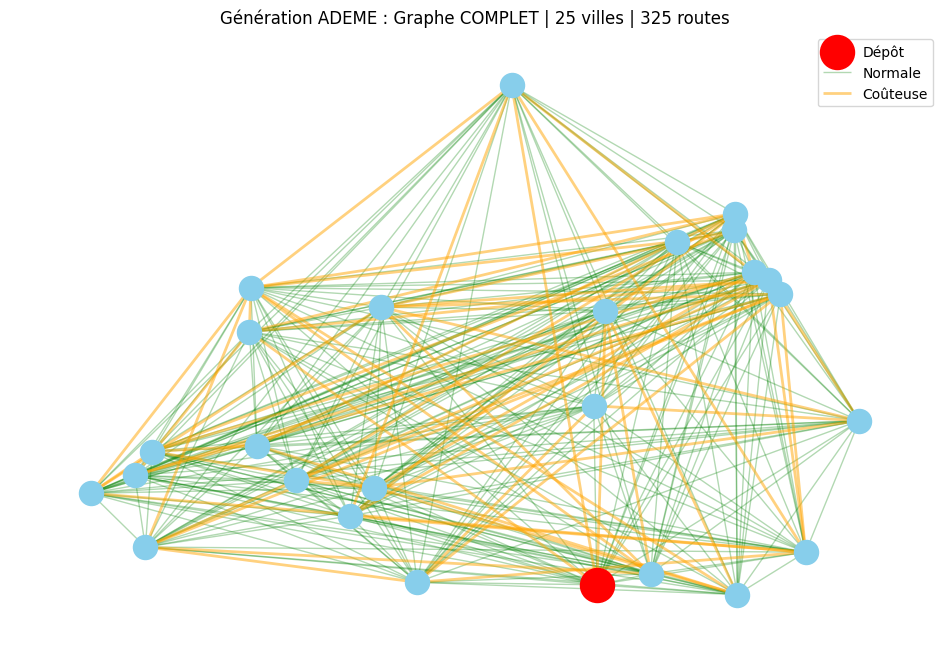

In [5]:
import random
import math
import networkx as nx
import matplotlib.pyplot as plt
from fontTools.diff import color


# ==========================================
# 1. CONFIGURATION DU RÉSEAU
# ==========================================
def reset_dataset(n_clients=25, m_camions=3, prob_couteuse=0.2, prob_barree=0.0, seed=42):
    random.seed(seed)
    global G, coords
    N_CLIENTS = n_clients
    M_CAMION = m_camions

# --- LE BOUTON DE CRASH TEST ---
    EST_GRAPHE_COMPLET = True  # Mettre sur True pour le Crash Test, False pour la vraie vie

    DEGRE_MOYEN = 3       # (Ignoré si est_graphe_complet = True)
    PROB_COUTEUSE = prob_couteuse  # 0.2 = 20% des routes sont coûteuses (4x plus chères)
    PROB_BARREE = prob_barree     # ⚠️ Mettre à 0.0 pour le crash test (pour empêcher le solveur de tricher)

    nodes = list(range(n_clients + 1))  # 0 = dépôt
    coords = {i: (random.uniform(0, 100), random.uniform(0, 100)) for i in nodes}

    def dist(i, j):
        return math.hypot(coords[i][0]-coords[j][0], coords[i][1]-coords[j][1])

# ==========================================
# 2. CONSTRUCTION DU GRAPHE
# ==========================================
    G = nx.Graph()
    G.add_nodes_from(nodes)

    if EST_GRAPHE_COMPLET:
    # On relie TOUS les noeuds entre eux
        for i in nodes:
            for j in range(i + 1, len(nodes)):
                d = dist(i, j)
                r = random.random()
            
                if r < PROB_BARREE:
                    G.add_edge(i, j, weight=9999, type='barree', is_backbone=False)
                elif r < PROB_BARREE + PROB_COUTEUSE:
                    G.add_edge(i, j, weight=d * 4, type='couteuse', is_backbone=False)
                else:
                    G.add_edge(i, j, weight=d, type='normale', is_backbone=False)

    else:
    # ==========================================
    # ÉTAPE A : L'ÉPINE DORSALE EN PÉTALES
    # ==========================================
        clients = list(range(1, N_CLIENTS + 1))
        random.shuffle(clients)
        morceaux = [clients[i::M_CAMION] for i in range(M_CAMION)]

        for boucle in morceaux:
            if not boucle: continue
            trajet = [0] + boucle + [0] 
            for k in range(len(trajet) - 1):
                u, v = trajet[k], trajet[k+1]
                if not G.has_edge(u, v):
                    d = dist(u, v)
                    type_r = 'couteuse' if random.random() < PROB_COUTEUSE else 'normale'
                    poids = d * 4 if type_r == 'couteuse' else d
                    G.add_edge(u, v, weight=poids, type=type_r, is_backbone=True)

    # ==========================================
    # ÉTAPE B : AJOUT DES ROUTES (Densité)
    # ==========================================
        N = len(nodes)
        degre_backbone = 2 
        degre_restant = max(0, DEGRE_MOYEN - degre_backbone)
        p_connexion = degre_restant / (N - 1)

        for i in nodes:
            for j in range(i + 1, N):
                if not G.has_edge(i, j):
                    if random.random() < p_connexion:
                        d = dist(i, j)
                        r = random.random()
                        if r < PROB_BARREE:
                            G.add_edge(i, j, weight=9999, type='barree', is_backbone=False)
                        elif r < PROB_BARREE + PROB_COUTEUSE:
                            G.add_edge(i, j, weight=d * 4, type='couteuse', is_backbone=False)
                        else:
                            G.add_edge(i, j, weight=d, type='normale', is_backbone=False)
    return G, coords, N_CLIENTS, EST_GRAPHE_COMPLET, DEGRE_MOYEN, M_CAMION

# ==========================================
# 3. VISUALISATION
# ==========================================

G, coords, n_clients, est_graphe_complet, degre_moyen, m_camions = reset_dataset()

plt.figure(figsize=(12, 8))
pos = coords
edges = G.edges(data=True)

nx.draw_networkx_nodes(G, pos, nodelist=range(1, n_clients+1), node_color='skyblue', node_size=300)
nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='red', node_size=600, label="Dépôt")

# Normales
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v,d in edges if d['type']=='normale'], edge_color='green', alpha=0.3, label="Normale")
# Coûteuses
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v,d in edges if d['type']=='couteuse'], edge_color='orange', width=2, alpha=0.5, label="Coûteuse")
# Barrées
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v,d in edges if d['type']=='barree'], edge_color='red', style='dashed', width=2, alpha=0.5, label="Barrée (9999)")

titre_mode = "Graphe COMPLET" if est_graphe_complet else f"Graphe CREUX (Degré ~{degre_moyen})"
plt.title(f"Génération ADEME : {titre_mode} | {n_clients} villes | {len(edges)} routes")
plt.legend()
plt.axis('off')
plt.show()

Analyse du graphe et lancement du solveur PuLP...
🚚 Camion 1 : Dépôt -> Ville 4 -> Ville 25 -> Ville 11 -> Ville 1 -> Ville 21 -> Ville 13 -> Ville 6 -> Ville 22 -> Ville 23 -> Ville 5 -> Ville 17 -> Ville 8 -> Ville 24 -> Ville 7 -> Ville 2 -> Ville 16 -> Ville 15 -> Ville 10 -> Ville 18 -> Ville 14 -> Ville 19 -> Ville 12 -> Ville 3 -> Dépôt
   ↳ Distance parcourue : 417.42

🚚 Camion 2 : Dépôt -> Ville 9 -> Dépôt
   ↳ Distance parcourue : 34.20

🚚 Camion 3 : Dépôt -> Ville 20 -> Dépôt
   ↳ Distance parcourue : 13.68



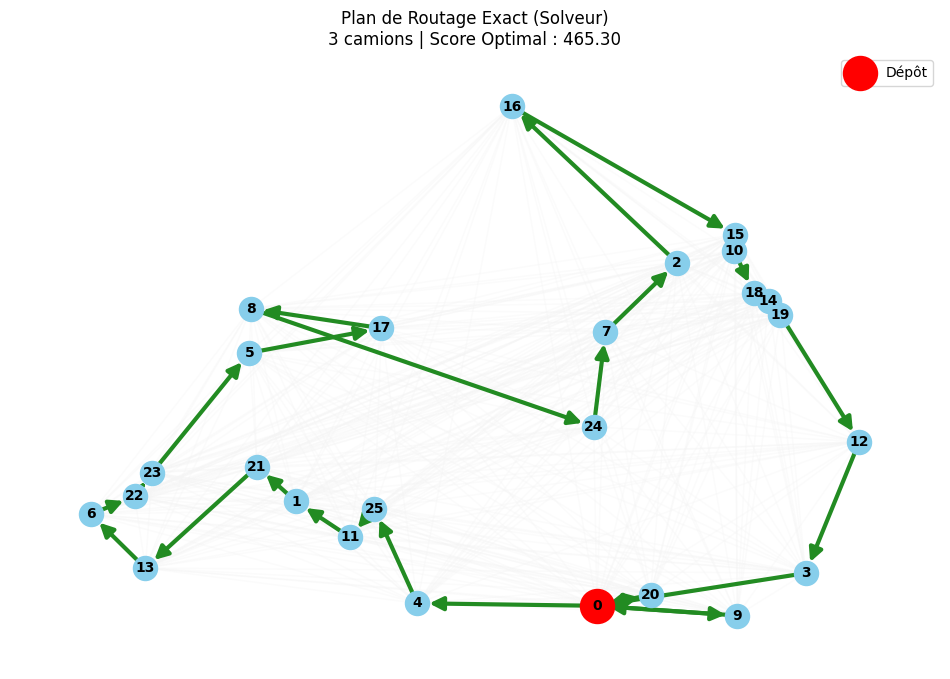

In [36]:
import pulp

# ==========================================
# 1. PRÉPARATION DU SOLVEUR
# ==========================================
def solveur():
    print("Analyse du graphe et lancement du solveur PuLP...")

    prob = pulp.LpProblem("mTSP_ADEME_Solveur_Exact", pulp.LpMinimize)

    arcs = []
    for u_node, v_node, data in G.edges(data=True):
        poids = data['weight']
        arcs.append((u_node, v_node, poids))
        arcs.append((v_node, u_node, poids))

    clients = list(range(1, n_clients + 1))
    nodes = [0] + clients

# ==========================================
# 2. VARIABLES DE DÉCISION
# =========================================
    x = pulp.LpVariable.dicts("x", ((i, j) for i, j, w in arcs), cat='Binary')
    u_ticket = pulp.LpVariable.dicts("u", clients, lowBound=1, upBound=n_clients, cat='Continuous')

# ==========================================
# 3. FONCTION OBJECTIF
# ==========================================
    prob += pulp.lpSum(w * x[i, j] for i, j, w in arcs), "Minimisation_Couts"

# ==========================================
# 4. LES CONTRAINTES
# ==========================================
# A. Entrées / Sorties uniques
    for c in clients:
        prob += pulp.lpSum(x[i, j] for i, j, w in arcs if j == c) == 1, f"Entree_{c}"
        prob += pulp.lpSum(x[i, j] for i, j, w in arcs if i == c) == 1, f"Sortie_{c}"

# B. Dépôt (m camions)
    prob += pulp.lpSum(x[0, j] for i, j, w in arcs if i == 0) == m_camions, "Sorties_Depot"
    prob += pulp.lpSum(x[i, 0] for i, j, w in arcs if j == 0) == m_camions, "Retours_Depot"

# C. MTZ
    M_mtz = n_clients - m_camions + 1
    for i, j, w in arcs:
        if i != 0 and j != 0:
            prob += u_ticket[i] - u_ticket[j] + M_mtz * x[i, j] <= M_mtz - 1, f"MTZ_{i}_{j}"

# ==========================================
# 5. RÉSOLUTION ET AFFICHAGE DÉTAILLÉ
# ==========================================
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    if pulp.LpStatus[prob.status] == 'Optimal':
        cout_final = pulp.value(prob.objective)
    
    # 5.1 Extraction des arêtes brutes
        routes_choisies = [(i, j) for i, j, w in arcs if pulp.value(x[i, j]) is not None and pulp.value(x[i, j]) > 0.5]
    
    # 5.2 Algorithme de reconstruction des chemins absolus
        successeurs = {node: [] for node in nodes}
        for origine, destination in routes_choisies:
            successeurs[origine].append(destination)
    
        tournees = []
    # On démarre depuis les sorties du Dépôt
        for premier_client in successeurs[0]:
            chemin = [0, premier_client]
            ville_actuelle = premier_client
            distance_camion = G[0][premier_client]['weight']
        
        # On remonte le fil jusqu'à retomber sur le Dépôt (0)
            while ville_actuelle != 0:
                ville_suivante = successeurs[ville_actuelle][0] # Chaque client n'a qu'un seul successeur
                chemin.append(ville_suivante)
                distance_camion += G[ville_actuelle][ville_suivante]['weight']
                ville_actuelle = ville_suivante
            
            tournees.append((chemin, distance_camion))
    
    # 5.3 Impression console des feuilles de route
        return tournees, clients, routes_choisies, cout_final

    else:
        return None, None, None, None

tournees, clients, routes_choisies, cout_final = solveur()

for idx, (chemin, distance) in enumerate(tournees):
        # Formatage du texte (ex: Dépôt -> Ville 3 -> Ville 5 -> Dépôt)
    texte_chemin = " -> ".join(["Dépôt" if v == 0 else f"Ville {v}" for v in chemin])
    print(f"🚚 Camion {idx + 1} : {texte_chemin}")
    print(f"   ↳ Distance parcourue : {distance:.2f}\n")
    
    # 5.4 Dessin du graphe (inchangé)
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, nodelist=clients, node_color='skyblue', node_size=300)
nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='red', node_size=600, label="Dépôt")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='whitesmoke', alpha=0.4)
nx.draw_networkx_edges(G, pos, edgelist=routes_choisies, edge_color='forestgreen', width=3, arrows=True, arrowsize=20, arrowstyle='-|>')

plt.title(f"Plan de Routage Exact (Solveur)\n{m_camions} camions | Score Optimal : {cout_final:.2f}")
plt.legend()
plt.axis('off')
plt.show()

--------------------------------------------------
🏁 APPRENTISSAGE TERMINÉ ! Meilleur score ACO : 485.97


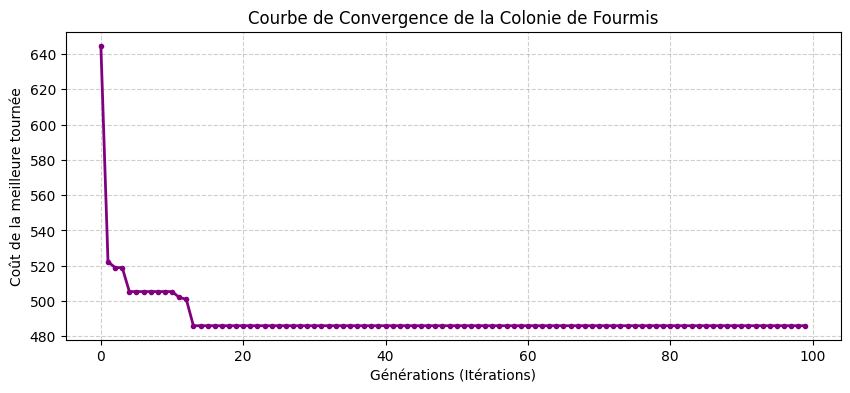

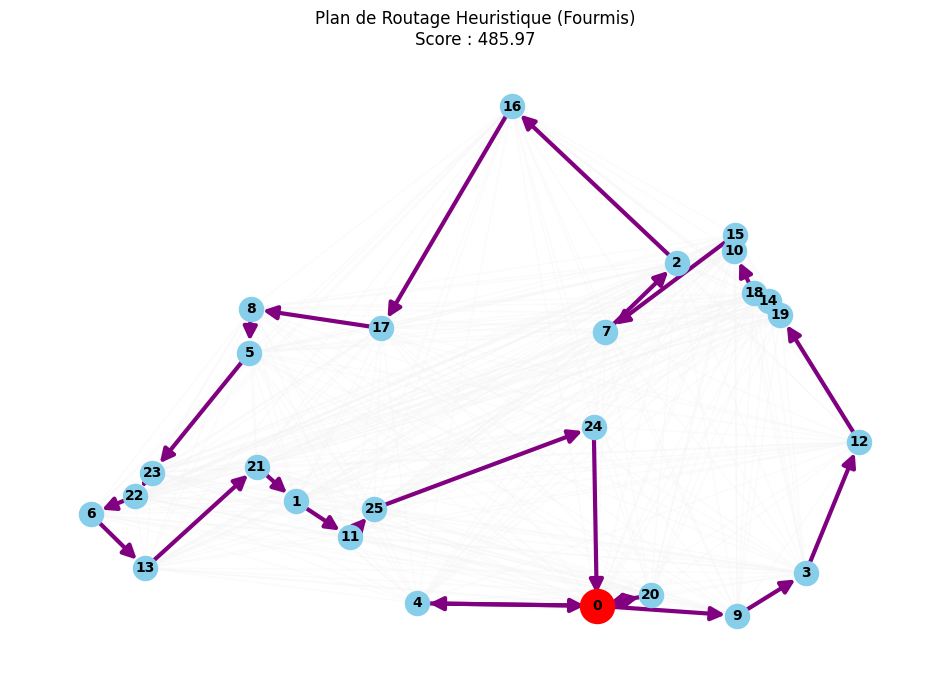

In [11]:
import numpy as np

# =====================================================================
# 1. TABLEAU DE BORD DES PARAMÈTRES ACO (À FAIRE VARIER !)
# =====================================================================

def fourmi(n_fourmis = 30, n_iterations = 100, alpha = 1.0, beta = 3.0, evaporation = 0.1, q_pheromone = 1000):
    N_FOURMIS = n_fourmis         # Taille de la colonie (combien de solutions testées par tour)
    N_ITERATIONS = n_iterations     # Nombre de générations (le temps d'apprentissage)

    ALPHA = alpha            # Poids de la Phéromone (La mémoire du groupe : "Est-ce qu'on est passé par là ?")
    BETA = beta             # Poids de la Visibilité (L'instinct : "Est-ce que la ville a l'air proche ?")
                       # => Mettre BETA plus fort que ALPHA aide à ignorer les routes chères (9999) !

    EVAPORATION = evaporation      # Taux d'évaporation (10% disparaissent par tour pour oublier les mauvaises routes)
    Q_PHEROMONE = q_pheromone     # Quantité de phéromones distribuée à la fin par les meilleures fourmis

# =====================================================================
# 2. INITIALISATION DU MONDE
# =====================================================================

# --- AJOUTE CETTE LIGNE ICI POUR CORRIGER LE BUG ---
    clients = list(range(1, n_clients + 1)) 
# ---------------------------------------------------

# On crée la matrice des phéromones. Au début, toutes les routes ont 1.0
    pheromones = {}
    for u, v in G.edges():
        pheromones[(u, v)] = 1.0
        pheromones[(v, u)] = 1.0  # L'odeur marche dans les deux sens

    meilleur_cout_global = float('inf')
    meilleur_trajet_global = []
    historique_apprentissage = []

# =====================================================================
# 3. LE CYCLE DE VIE DES FOURMIS (Apprentissage)
# =====================================================================
    for iteration in range(N_ITERATIONS):
        trajets_de_la_generation = []
        couts_de_la_generation = []
    
    # Chaque fourmi tente de résoudre le problème (m camions)
        for f in range(N_FOURMIS):
            villes_a_visiter = set(clients)
            camions_disponibles = m_camions - 1  # -1 car le premier camion démarre tout de suite
        
            trajets_fourmi = []
            trajet_actuel = [0] # Le camion 1 part du dépôt
            cout_fourmi = 0
            fourmi_bloquee = False
        
        # Tant qu'il reste des clients à livrer
            while villes_a_visiter:
                ville_actuelle = trajet_actuel[-1]
            
            # --- RÈGLE MÉTIER 1 (Mise à jour) : LA COURSE DE RELAIS STRICTE ---
                destinations_possibles = list(villes_a_visiter)
            
            # Règle Anti-Famine : Si le nombre de villes restantes est égal au nombre 
            # de camions au dépôt, le camion actuel est OBLIGÉ de rentrer !
                if len(villes_a_visiter) <= camions_disponibles and ville_actuelle != 0:
                    destinations_possibles = [0] # Retour forcé (0 est la seule option)
                
            # Sinon, s'il reste des camions, le retour est juste une option parmi d'autres
                elif camions_disponibles > 0 and ville_actuelle != 0:
                    destinations_possibles.append(0)
                
            # --- CALCUL DES PROBABILITÉS ---
                probabilites = []
                for dest in destinations_possibles:
                    if G.has_edge(ville_actuelle, dest):
                        tau = pheromones[(ville_actuelle, dest)]
                    
                    # --- RÈGLE MÉTIER 2 : ROUTES BARRÉES ET COÛTEUSES ---
                    # La visibilité est l'inverse du coût (1 / Distance). 
                    # Si la route est barrée (9999), eta devient 0.0001. 
                    # La probabilité de la choisir frôle le zéro absolu !
                        eta = 1.0 / G[ville_actuelle][dest]['weight'] 
                    
                    # Formule officielle de l'ACO
                        score = (tau ** ALPHA) * (eta ** BETA)
                        probabilites.append(score)
                    else:
                        probabilites.append(0) # La route n'existe pas physiquement
            
                somme_probs = sum(probabilites)
                if somme_probs == 0:
                    fourmi_bloquee = True # Impasse totale (très rare avec l'épine dorsale)
                    break
                
            # On transforme les scores en pourcentages (0 à 1)
                probabilites = [p / somme_probs for p in probabilites]
            
            # La fourmi lance les dés pour choisir la prochaine route
                prochaine_ville = random.choices(destinations_possibles, weights=probabilites)[0]
            
            # On met à jour le trajet et le porte-monnaie
                cout_fourmi += G[ville_actuelle][prochaine_ville]['weight']
            
                if prochaine_ville == 0:
                # La fourmi a choisi de rentrer ! Le camion actuel a fini sa journée.
                    trajet_actuel.append(0)
                    trajets_fourmi.append(trajet_actuel)
                    trajet_actuel = [0] # Le nouveau camion démarre du dépôt
                    camions_disponibles -= 1
                else:
                # La fourmi continue sa route chez un client
                    trajet_actuel.append(prochaine_ville)
                    villes_a_visiter.remove(prochaine_ville)
                
            if fourmi_bloquee:
                continue # Cette fourmi est morte dans un cul-de-sac, on passe à la suivante
            
        # Fin de journée : Le tout dernier camion doit obligatoirement rentrer au dépôt
            cout_fourmi += G[trajet_actuel[-1]][0]['weight']
            trajet_actuel.append(0)
            trajets_fourmi.append(trajet_actuel)
        
        # Sauvegarde de la solution trouvée par cette fourmi
            trajets_de_la_generation.append(trajets_fourmi)
            couts_de_la_generation.append(cout_fourmi)
        
        # Est-ce le nouveau record du monde ?
            if cout_fourmi < meilleur_cout_global:
                meilleur_cout_global = cout_fourmi
                meilleur_trajet_global = trajets_fourmi

    # =====================================================================
    # 4. MISE À JOUR DES PHÉROMONES (La nature reprend ses droits)
    # =====================================================================
    # Le vent souffle, les phéromones s'évaporent (pour oublier les mauvaises routes)
        for route in pheromones:
            pheromones[route] *= (1.0 - EVAPORATION)
        
    # Les fourmis rentrées au nid déposent de nouvelles phéromones.
    # Plus le trajet de la fourmi était court, plus elle dépose de phéromones !
        for trajets_f, cout_f in zip(trajets_de_la_generation, couts_de_la_generation):
            depot = Q_PHEROMONE / cout_f
            for trajet_camion in trajets_f:
                for i in range(len(trajet_camion) - 1):
                    u, v = trajet_camion[i], trajet_camion[i+1]
                    pheromones[(u, v)] += depot
                
        if meilleur_cout_global != float('inf'):
            historique_apprentissage.append(meilleur_cout_global)
    return meilleur_cout_global, historique_apprentissage, meilleur_trajet_global

meilleur_cout_global, historique_apprentissage, meilleur_trajet_global = fourmi()
# =====================================================================
# 5. RÉSULTATS ET AFFICHAGES
# =====================================================================
print("-" * 50)
print(f"🏁 APPRENTISSAGE TERMINÉ ! Meilleur score ACO : {meilleur_cout_global:.2f}")

# Dessin de la Courbe de Convergence (C'EST CE GRAPHIQUE QUI RAPPORTE DES POINTS !)
plt.figure(figsize=(10, 4))
plt.plot(historique_apprentissage, color='purple', linewidth=2, marker='o', markersize=3)
plt.title("Courbe de Convergence de la Colonie de Fourmis")
plt.xlabel("Générations (Itérations)")
plt.ylabel("Coût de la meilleure tournée")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Dessin de la Carte Finale (Comme pour le solveur)
plt.figure(figsize=(12, 8))
pos = coords
nx.draw_networkx_nodes(G, pos, nodelist=range(1, n_clients+1), node_color='skyblue', node_size=300)
nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='red', node_size=600, label="Dépôt")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='whitesmoke', alpha=0.4)

# On extrait les arêtes du meilleur trajet trouvé par les fourmis
aretes_finales = []
for trajet_camion in meilleur_trajet_global:
    for i in range(len(trajet_camion) - 1):
        aretes_finales.append((trajet_camion[i], trajet_camion[i+1]))

nx.draw_networkx_edges(G, pos, edgelist=aretes_finales, edge_color='purple', width=3, arrows=True, arrowsize=20, arrowstyle='-|>')
plt.title(f"Plan de Routage Heuristique (Fourmis)\nScore : {meilleur_cout_global:.2f}")
plt.axis('off')
plt.show()


# Plan d'expérience

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

ant=10
alpha=1
beta=2.0
rho=0.1

In [51]:
def execAlgoOneParam(nbIt, arrayParam, name_param):
    LMean, LStd, LMedian, LAbsMedian, LTpsMean = [], [], [], [], []
    for param in arrayParam:
        LRes = []
        LTps = []
        for i in range(nbIt):
            match name_param:
                case "ant":
                    start = time.time()
                    res, trash, trash = fourmi(int(param), n_iter, alpha, beta, rho)
                    end = time.time()
                    LRes.append(res)
                case 'it':
                    start = time.time()
                    res, trash, trash = fourmi(ant, int(param), alpha, beta, rho)
                    end = time.time()
                    LRes.append(res)
                case "alpha":
                    start = time.time()
                    res, trash, trash = fourmi(ant, n_iter, param, beta, rho)
                    end = time.time()
                    LRes.append(res)
                case "beta":
                    start = time.time()
                    res, trash, trash = fourmi(ant, n_iter, alpha, param, rho)
                    end = time.time()
                    LRes.append(res)
                case "rho":
                    start = time.time()
                    res, trash, trash = fourmi(ant, n_iter, alpha, beta, param)
                    end = time.time()
                    LRes.append(res)

                case _:
                    exit()

            LTps.append(end - start)

        LMean.append(np.mean(LRes))
        LStd.append(np.std(LRes))
        LMedian.append(np.median(LRes))
        LAbsMedian.append(np.mean(np.abs(LRes - np.mean(LRes))))
        LTpsMean.append(np.mean(LTps))

    return LMean, LStd, LMedian, LAbsMedian, LTpsMean


In [60]:
def plotOneParam(arrayParam, LMean, LStd, LMedian, LAbsMedian, LTpsMean, name_param):
    plt.figure(figsize=(14, 10))

    plt.subplot(2, 1, 1)

    # Courbe de moyenne
    plt.plot(arrayParam, LMean, label='Moyenne')

    # Bande écart-type
    LMean = np.array(LMean)
    LStd = np.array(LStd)

    plt.fill_between(
        arrayParam,
        LMean - LStd,
        LMean + LStd,
        alpha=0.3,
        label='Écart-type'
    )

    # Autres métriques (optionnel mais utile)
    plt.plot(arrayParam, LMedian, linestyle='--', label='Médiane')
    plt.plot(arrayParam, LAbsMedian, linestyle=':', label='Écart moyen absolu')
    plt.axhline(y=cout_final, linestyle='-', color='red', label='Meilleure solution')


    plt.xlabel(name_param)
    plt.ylabel('Valeurs')
    plt.title(f'Statistiques des résultats ({name_param})')
    plt.legend()
    plt.grid()

    # === SUBPLOT 2 : temps ===
    plt.subplot(2, 1, 2)
    plt.plot(arrayParam, LTpsMean, label='Temps', color='black')

    plt.xlabel(name_param)
    plt.ylabel('Temps (s)')
    plt.title(f'Temps d’exécution ({name_param})')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

In [20]:
# array_ants = np.linspace(1, 75, 4)
# array_it = np.linspace(1, 75, 4)
# array_alpha = np.linspace(0, 5, 4)
# array_beta = np.linspace(1, 5, 4)
# array_rho = np.linspace(0, 1, 4)

array_ants = [10, 30, 50, 75]
array_it = [10, 30, 50, 75]
array_alpha = [0.5, 2, 4, 5]
array_beta = [1, 2, 3, 5]
array_rho = [0.1, 0.4, 0.75, 1]

n_iter=3


In [67]:

LMeanAnts, LStdAnts, LMedianAnts, LAbsMedianAnts, LTpsMeanAnts = execAlgoOneParam(n_iter, array_ants, "ant")
LMeanIt, LStdIt, LMedianIt, LAbsMedianIt, LTpsMeanIt = execAlgoOneParam(n_iter, array_it, "it")
LMeanAlpha, LStdAlpha, LMedianAlpha, LAbsMedianAlpha, LTpsMeanAlpha = execAlgoOneParam(n_iter, array_alpha, "alpha")
LMeanBeta, LStdBeta, LMedianBeta, LAbsMedianBeta, LTpsMeanBeta = execAlgoOneParam(n_iter, array_beta, "beta")
LMeanRho, LStdRho, LMedianRho, LAbsMedianRho, LTpsMeanRho = execAlgoOneParam(n_iter, array_rho, "rho")


print("Start plot...")




Start plot...


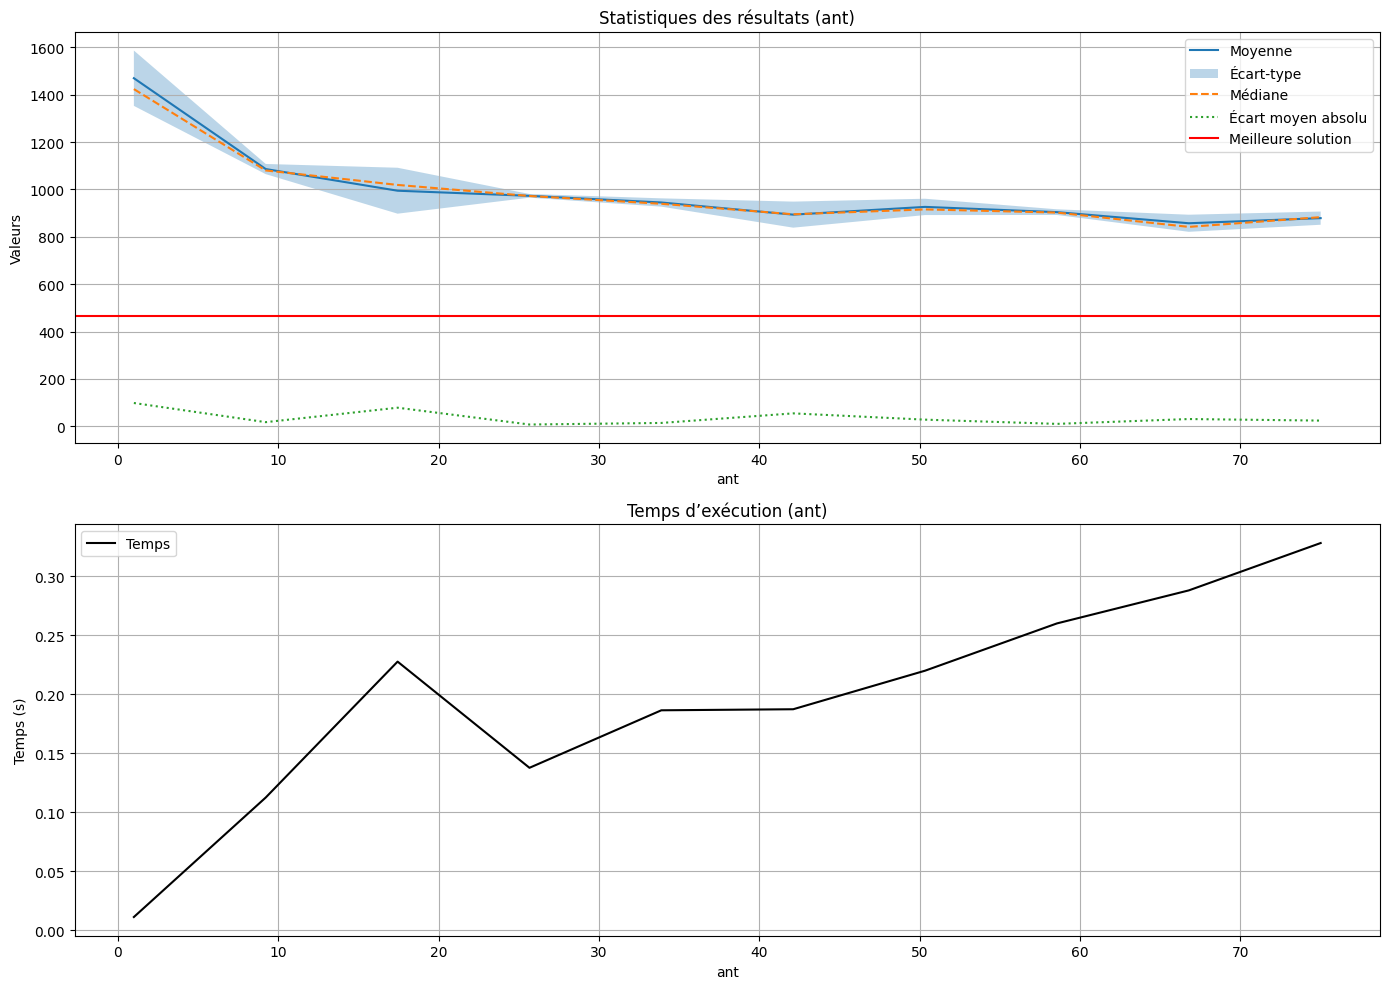

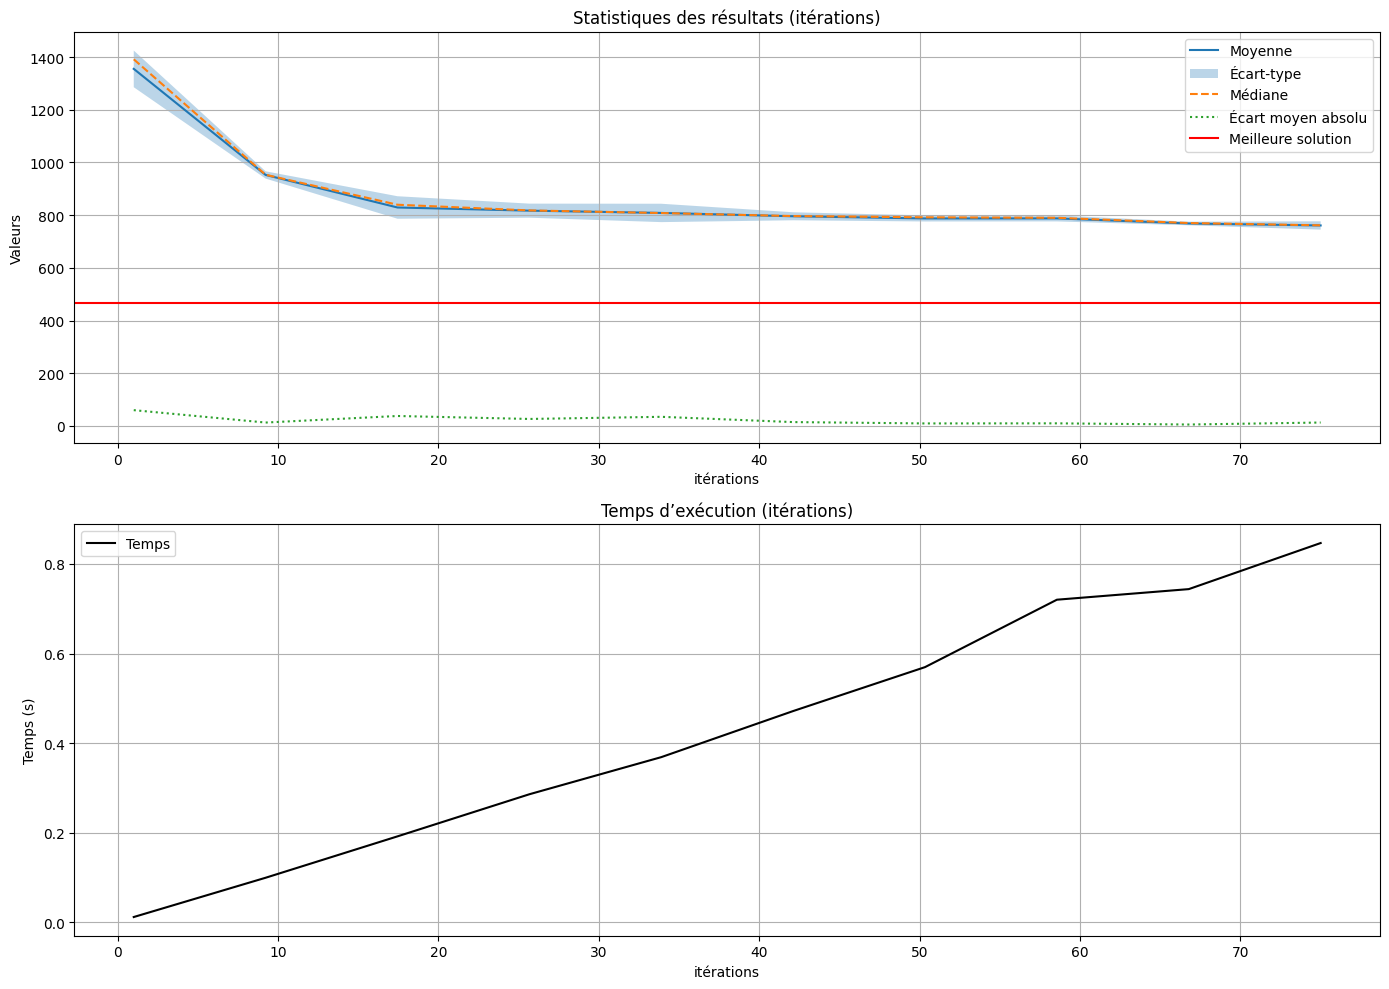

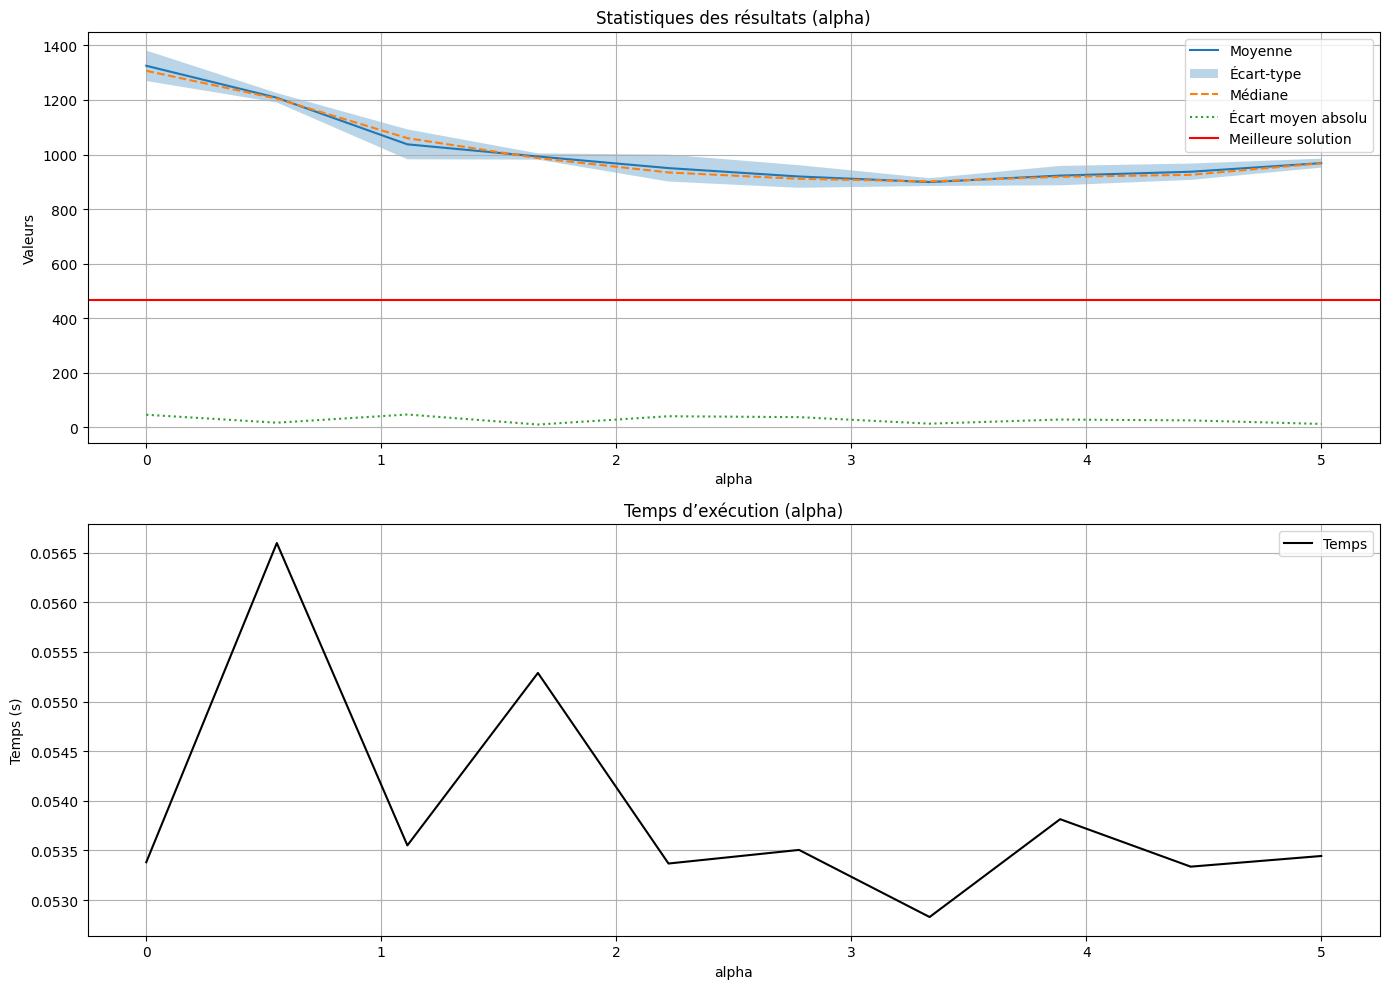

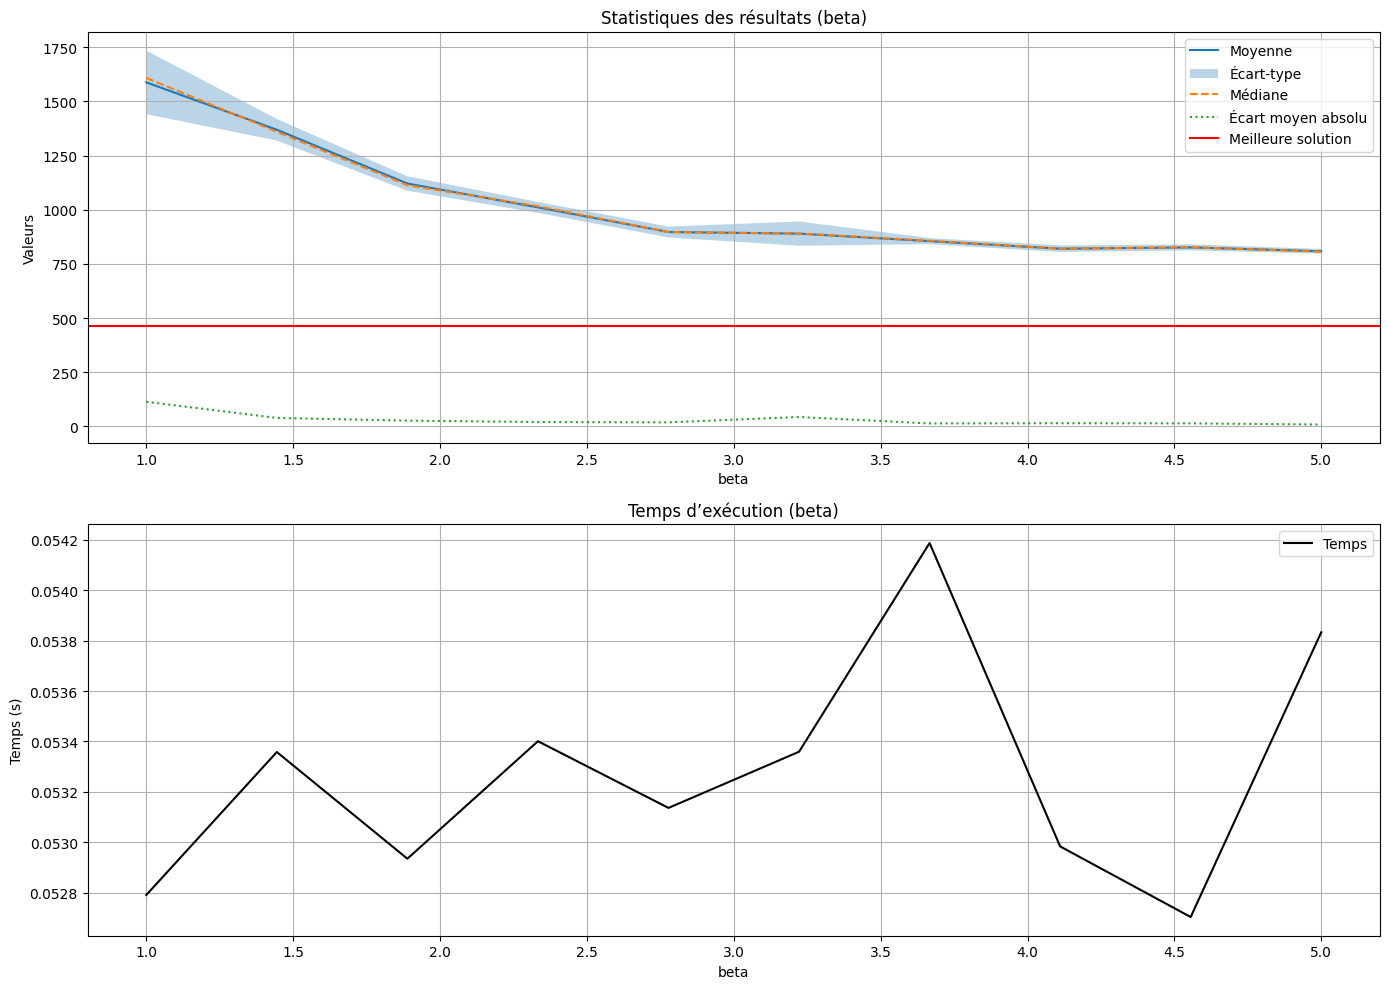

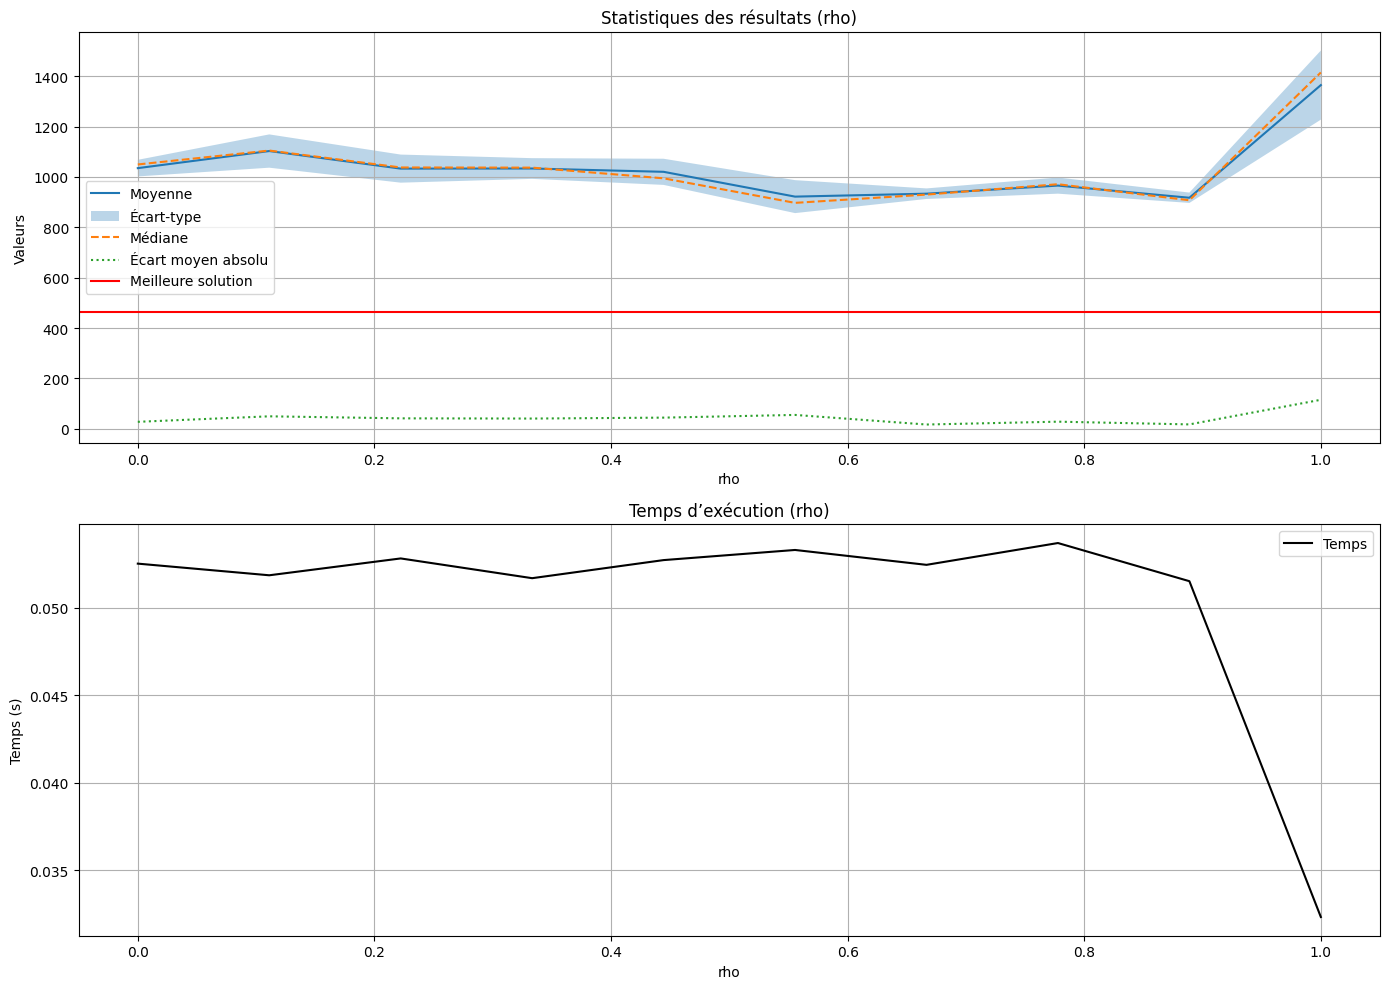

In [68]:
plotOneParam(array_ants, LMeanAnts, LStdAnts, LMedianAnts, LAbsMedianAnts, LTpsMeanAnts, "ant")
plotOneParam(array_it, LMeanIt, LStdIt, LMedianIt, LAbsMedianIt, LTpsMeanIt, "itérations")
plotOneParam(array_alpha, LMeanAlpha, LStdAlpha, LMedianAlpha, LAbsMedianAlpha, LTpsMeanAlpha, "alpha")
plotOneParam(array_beta, LMeanBeta, LStdBeta, LMedianBeta, LAbsMedianBeta, LTpsMeanBeta, "beta")
plotOneParam(array_rho, LMeanRho, LStdRho, LMedianRho, LAbsMedianRho, LTpsMeanRho, "rho")

In [25]:
def execAlgoMultiParam(nbIt, array_ants, array_it, array_alpha, array_beta, array_rho):

    results = []

    for ant, it, alpha, beta, rho in product(
        array_ants, array_it, array_alpha, array_beta, array_rho
    ):
        LRes = []
        LTps = []

        for i in range(nbIt):
            start = time.time()

            res, _, _ = fourmi(int(ant), int(it), alpha, beta, rho)

            end = time.time()

            LRes.append(res)
            LTps.append(end - start)

        results.append({
            "ant": int(ant),
            "it": int(it),
            "alpha": alpha,
            "beta": beta,
            "rho": rho,
            "mean": np.mean(LRes),
            "std": np.std(LRes),
            "best": np.min(LRes),
            "time": np.mean(LTps)
        })

    return results

In [21]:
import pandas as pd
import seaborn as sns
from itertools import product

# 36 min --> réduire les tailles pour moins de temps
results = execAlgoMultiParam(n_iter, array_ants, array_it, array_alpha, array_beta, array_rho)

df = pd.DataFrame(results)

In [28]:
from itertools import combinations

def plot_pairwise_heatmaps(df, fixed_values):
    params = ["ant", "it", "alpha", "beta", "rho"]

    pairs = list(combinations(params, 2))

    n = len(pairs)
    cols = 3
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(18, 5 * rows))

    for idx, (p1, p2) in enumerate(pairs):
        plt.subplot(rows, cols, idx + 1)

        pivot = df.pivot_table(values="mean", index=p1, columns=p2, aggfunc="mean")

        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="viridis")
        plt.title(f"{p1} vs {p2}")

    plt.tight_layout()
    plt.show()

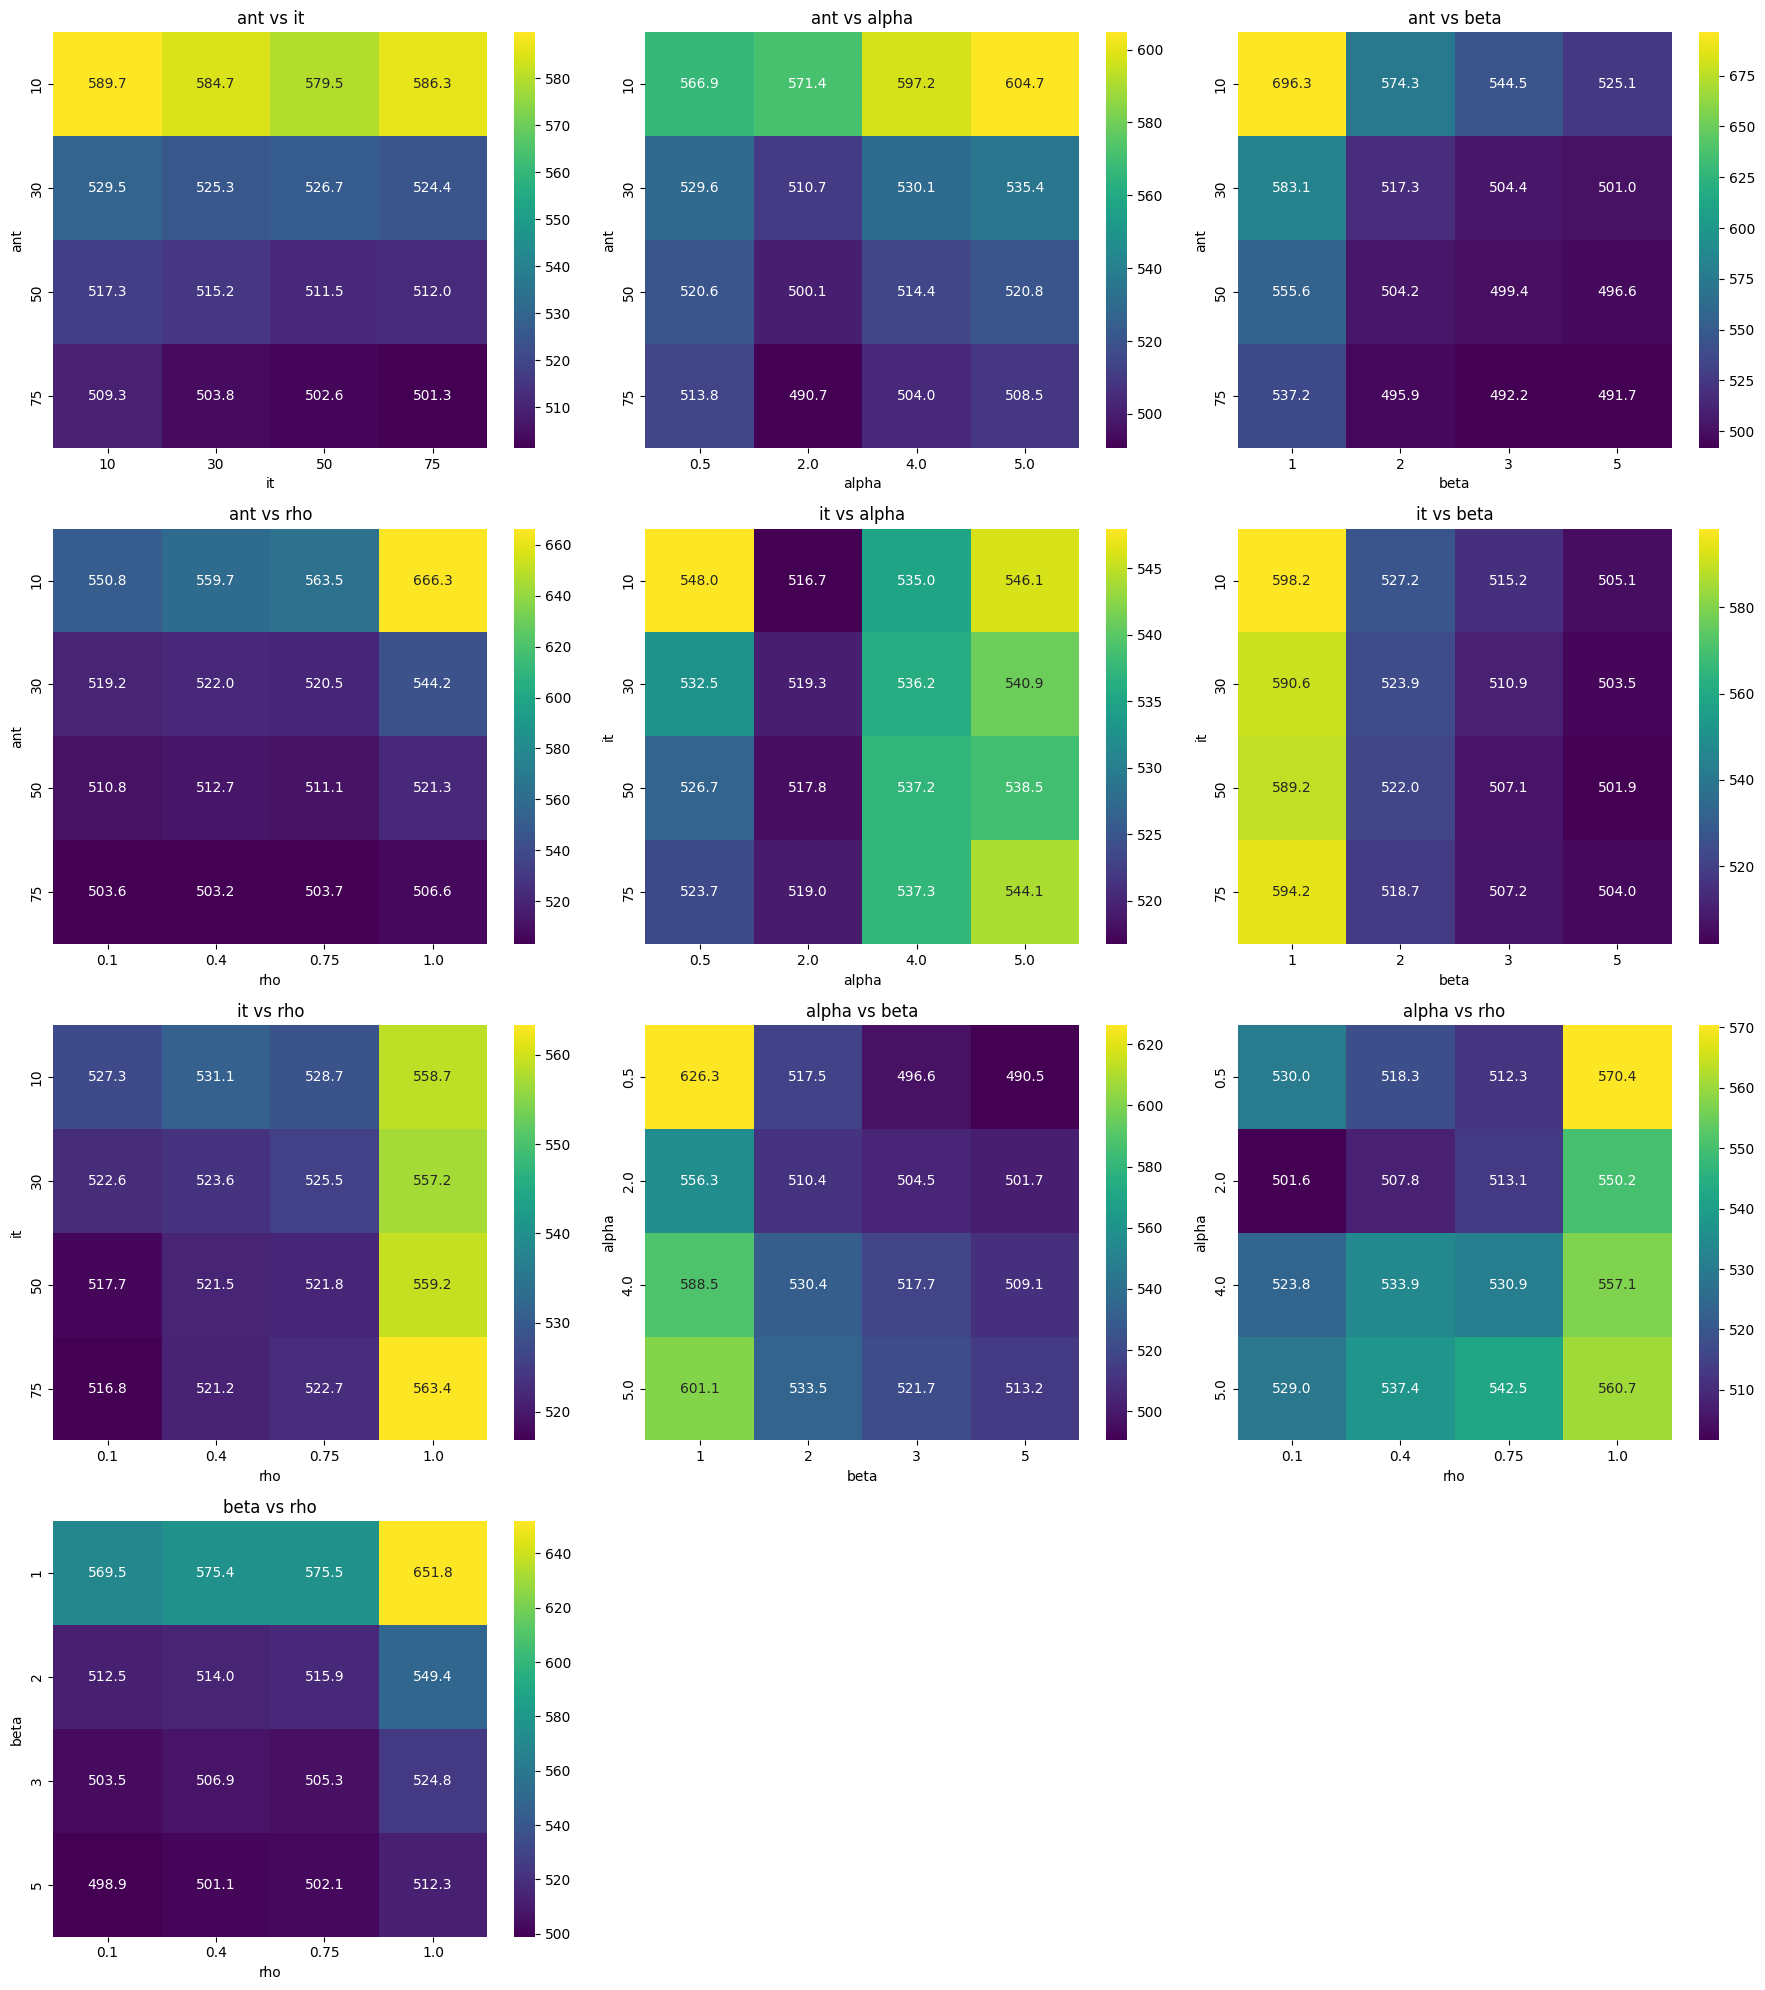

In [29]:
fixed_values = {
    "ant": df["ant"].median(),
    "it": df["it"].median(),
    "alpha": df["alpha"].median(),
    "beta": df["beta"].median(),
    "rho": df["rho"].median()
}

plot_pairwise_heatmaps(df, fixed_values)